In [ ]:
!pip install matplotlib

In [1]:
"""
PISI - Notebook Final: Pipeline Completo de Classificação de Recuperação
========================================================================
Target  : Prever se a recuperação do dia SEGUINTE será crítica
Dataset : WHOOP Fitness Dataset (Kaggle - 100k registros, 286 usuários)
Tarefa  : Classificação binária com balanceamento (SMOTE), XAI (SHAP)
          e comparação com o melhor modelo entregue na 3VA.
"""

# ==========================================================
# CÉLULA 1 — Imports
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, f1_score,
    precision_score, recall_score, accuracy_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap

print("✅ Imports OK")

✅ Imports OK


In [2]:
# ==========================================================
# CÉLULA 2 — Carregamento e inspeção dos dados
# ==========================================================
from Dashboard.data_loader import data_manager

data_manager.load_data()
df_raw = data_manager.get_clean_df()

print(f"✅ Dataset: {df_raw.shape[0]:,} linhas × {df_raw.shape[1]} colunas")
print(f"   Usuários: {df_raw['user_id'].nunique()} | Período: {df_raw['date'].min().date()} → {df_raw['date'].max().date()}")
print(f"\n   recovery_score — média: {df_raw['recovery_score'].mean():.1f} | "
      f"mediana: {df_raw['recovery_score'].median():.1f} | "
      f"p25: {df_raw['recovery_score'].quantile(0.25):.1f} | "
      f"p10: {df_raw['recovery_score'].quantile(0.10):.1f}")


📂 Carregando dados do Excel...
📄 Arquivo encontrado: whoop_fitness_dataset_100k.xlsx
✅ 100,000 registros carregados

🔧 INICIANDO PRÉ-PROCESSAMENTO
✅ Datas convertidas

📊 Limpando HRV...

📊 Limpando HRV Baseline...

📊 Limpando sleep_hours...

📊 Limpando light_sleep_hours...

📊 Limpando deep_sleep_hours...

📊 Limpando rem_sleep_hours...

📊 Limpando Recovery Score...

📊 Limpando resting_heart_rate...

📊 Limpando avg_heart_rate...

📊 Limpando max_heart_rate...

📊 Limpando Idade...

📊 Limpando Calorias...

📊 Limpando Duração da Atividade...
   ✅ Criada coluna 'activity_duration_hours'

📊 Limpando Frequência Respiratória...

📊 Limpando Desvio de Temperatura...

📊 Limpando Strain da Atividade...

📊 Limpando Tempo para Dormir...

📊 Limpando Despertares...

📊 Limpando Calorias da Atividade...

📊 Limpando Peso...

📊 Limpando Altura...

📊 Limpando hr_zone_1_min...

📊 Limpando hr_zone_2_min...

📊 Limpando hr_zone_3_min...

📊 Limpando hr_zone_4_min...

📊 Limpando hr_zone_5_min...

📊 Limpando Trein

In [3]:
# ==========================================================
# CÉLULA 3 — Engenharia de features + definição do TARGET
# ==========================================================
df = df_raw.sort_values(['user_id', 'date']).copy()

# --- Médias móveis dos últimos 3 dias (acúmulo de fadiga/recuperação) ---
for col, alias in [('sleep_hours', 'media_sono_3dias'),
                   ('hrv',         'media_vfc_3dias'),
                   ('day_strain',  'media_strain_3dias'),
                   ('sleep_efficiency', 'media_efic_sono_3dias')]:
    df[alias] = (df.groupby('user_id')[col]
                   .transform(lambda x: x.rolling(3, min_periods=1).mean()))

# --- Target: recuperação CRÍTICA no dia seguinte ---
# Usamos o percentil 33 como limiar (1/3 pior dos dias de recuperação).
# Isso garante ~33% de positivos — muito melhor que o limiar fixo de 40
# que gerava apenas 5.6%, inviabilizando o aprendizado.
df['recovery_amanha'] = df.groupby('user_id')['recovery_score'].shift(-1)

LIMIAR = df['recovery_score'].quantile(0.33)
print(f"Limiar do target (percentil 33 do recovery_score): {LIMIAR:.1f}")

df['target_amanha'] = (df['recovery_amanha'] < LIMIAR).astype(int)

# Remover a última linha de cada usuário (sem dados de amanhã)
df_ml = df.dropna(subset=['recovery_amanha']).copy()

print(f"\nDistribuição do target:")
vc = df_ml['target_amanha'].value_counts()
print(f"  0 (Recuperação OK)    : {vc[0]:,} ({vc[0]/len(df_ml):.1%})")
print(f"  1 (Recuperação Crítica): {vc[1]:,} ({vc[1]/len(df_ml):.1%})")


Limiar do target (percentil 33 do recovery_score): 57.4

Distribuição do target:
  0 (Recuperação OK)    : 66,861 (67.1%)
  1 (Recuperação Crítica): 32,853 (32.9%)


In [4]:
# ==========================================================
# CÉLULA 4 — Seleção de features (sem vazamento)
# ==========================================================
# NOTA: recovery_score, tomorrow_recovery_score e derivadas de 'recovery_score'
# NÃO entram como features — seriam vazamento direto do target.
# day_strain, hrv, resting_heart_rate são medições do DIA ATUAL e é legítimo
# usá-las para prever a RECUPERAÇÃO DE AMANHÃ (não há leakage temporal).

FEATURES = [
    # Dados fisiológicos do dia atual
    'sleep_hours',
    'sleep_efficiency',
    'hrv',
    'resting_heart_rate',
    'day_strain',

    # Acúmulo dos últimos 3 dias
    'media_sono_3dias',
    'media_vfc_3dias',
    'media_strain_3dias',
    'media_efic_sono_3dias',

    # Dados demográficos (fixos por usuário)
    'age',
    'weight_kg',
]

X = df_ml[FEATURES]
y = df_ml['target_amanha']

print(f"Features selecionadas: {len(FEATURES)}")
print(f"Amostras para ML: {len(X):,}")
print(f"\nNulos por feature:")
print(X.isnull().sum()[X.isnull().sum() > 0])

Features selecionadas: 11
Amostras para ML: 99,714

Nulos por feature:
sleep_hours         17488
hrv                  4392
media_sono_3dias      776
media_vfc_3dias       190
dtype: int64


In [5]:
# ==========================================================
# CÉLULA 5 — Split estratificado (80/20)
# ==========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino : {len(X_train):,} amostras | "
      f"Positivos: {y_train.sum():,} ({y_train.mean():.1%})")
print(f"Teste  : {len(X_test):,} amostras | "
      f"Positivos: {y_test.sum():,} ({y_test.mean():.1%})")


Treino : 79,771 amostras | Positivos: 26,282 (32.9%)
Teste  : 19,943 amostras | Positivos: 6,571 (32.9%)


In [6]:
# ==========================================================
# CÉLULA 6 — MODELO PISI (Random Forest + SMOTE)
# ==========================================================
print("⏳ Treinando Pipeline PISI (Imputer → Scaler → SMOTE → Random Forest)...")

pipeline_pisi = ImbPipeline([
    ('imputer',    SimpleImputer(strategy='median')),
    ('scaler',     StandardScaler()),
    ('smote',      SMOTE(random_state=42, k_neighbors=5)),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        class_weight='balanced',   # dupla proteção além do SMOTE
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_pisi.fit(X_train, y_train)
print("✅ Treinamento concluído!")

# Previsões
y_pred_pisi  = pipeline_pisi.predict(X_test)
y_proba_pisi = pipeline_pisi.predict_proba(X_test)[:, 1]

print("\n" + "="*55)
print("  MÉTRICAS — MODELO PISI (RF + SMOTE)")
print("="*55)
print(classification_report(y_test, y_pred_pisi,
                             target_names=['Recuperação OK', 'Recuperação Crítica']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_pisi):.4f}")


⏳ Treinando Pipeline PISI (Imputer → Scaler → SMOTE → Random Forest)...
✅ Treinamento concluído!

  MÉTRICAS — MODELO PISI (RF + SMOTE)
                     precision    recall  f1-score   support

     Recuperação OK       0.78      0.66      0.71     13372
Recuperação Crítica       0.47      0.63      0.54      6571

           accuracy                           0.65     19943
          macro avg       0.63      0.64      0.63     19943
       weighted avg       0.68      0.65      0.66     19943

AUC-ROC: 0.6849


In [7]:
# ==========================================================
# CÉLULA 7 — MODELO 3VA (Gradient Boosting, sem SMOTE)
# O modelo da 3VA usava features sem as médias móveis e sem
# balanceamento — reproduzimos aqui para comparação justa.
# ==========================================================
print("⏳ Treinando Modelo 3VA (Gradient Boosting — baseline para comparação)...")

# Usamos as mesmas features mas sem SMOTE (como era na 3VA)
from sklearn.pipeline import Pipeline as SkPipeline

pipeline_3va = SkPipeline([
    ('imputer',    SimpleImputer(strategy='median')),
    ('scaler',     StandardScaler()),
    ('classifier', GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        random_state=42
    ))
])

pipeline_3va.fit(X_train, y_train)
print("✅ Treinamento concluído!")

y_pred_3va  = pipeline_3va.predict(X_test)
y_proba_3va = pipeline_3va.predict_proba(X_test)[:, 1]

print("\n" + "="*55)
print("  MÉTRICAS — MODELO 3VA (Gradient Boosting, sem SMOTE)")
print("="*55)
print(classification_report(y_test, y_pred_3va,
                             target_names=['Recuperação OK', 'Recuperação Crítica']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_3va):.4f}")


⏳ Treinando Modelo 3VA (Gradient Boosting — baseline para comparação)...
✅ Treinamento concluído!

  MÉTRICAS — MODELO 3VA (Gradient Boosting, sem SMOTE)
                     precision    recall  f1-score   support

     Recuperação OK       0.72      0.90      0.80     13372
Recuperação Crítica       0.60      0.30      0.40      6571

           accuracy                           0.70     19943
          macro avg       0.66      0.60      0.60     19943
       weighted avg       0.68      0.70      0.67     19943

AUC-ROC: 0.7087


In [8]:
# ==========================================================
# CÉLULA 8 — Tabela comparativa resumida
# ==========================================================
def metricas_resumo(y_true, y_pred, y_proba, nome):
    return {
        'Modelo': nome,
        'Acurácia':   f"{accuracy_score(y_true, y_pred):.3f}",
        'Precisão¹':  f"{precision_score(y_true, y_pred):.3f}",
        'Recall¹':    f"{recall_score(y_true, y_pred):.3f}",
        'F1¹':        f"{f1_score(y_true, y_pred):.3f}",
        'AUC-ROC':    f"{roc_auc_score(y_true, y_proba):.3f}",
    }

resumo = pd.DataFrame([
    metricas_resumo(y_test, y_pred_pisi, y_proba_pisi, 'RF + SMOTE (PISI)'),
    metricas_resumo(y_test, y_pred_3va,  y_proba_3va,  'Gradient Boosting (3VA)'),
])
print("\n" + "="*65)
print("  COMPARATIVO PISI vs 3VA   ¹ = classe 1 (Recuperação Crítica)")
print("="*65)
print(resumo.to_string(index=False))


  COMPARATIVO PISI vs 3VA   ¹ = classe 1 (Recuperação Crítica)
                 Modelo Acurácia Precisão¹ Recall¹   F1¹ AUC-ROC
      RF + SMOTE (PISI)    0.647     0.474   0.632 0.541   0.685
Gradient Boosting (3VA)    0.704     0.603   0.295 0.396   0.709


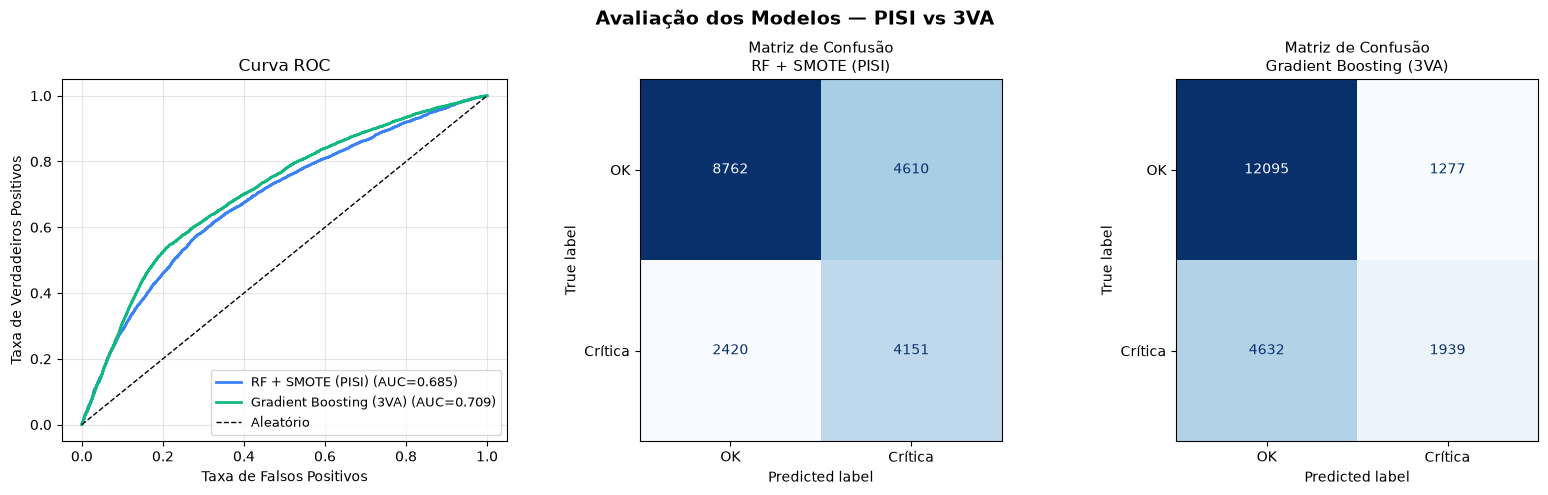

✅ Gráfico salvo em 'comparativo_modelos.png'


In [9]:
# ==========================================================
# CÉLULA 9 — Gráficos: ROC + Matrizes de Confusão
# ==========================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Avaliação dos Modelos — PISI vs 3VA', fontsize=14, fontweight='bold')

# --- ROC ---
ax = axes[0]
for nome, y_proba, cor in [
    ('RF + SMOTE (PISI)', y_proba_pisi, '#3B82F6'),
    ('Gradient Boosting (3VA)', y_proba_3va, '#10B981'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{nome} (AUC={auc:.3f})", color=cor, lw=2)

ax.plot([0,1],[0,1], 'k--', lw=1, label='Aleatório')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curva ROC')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

# --- Matrizes de Confusão ---
for ax, y_pred, titulo in [
    (axes[1], y_pred_pisi, 'RF + SMOTE (PISI)'),
    (axes[2], y_pred_3va,  'Gradient Boosting (3VA)'),
]:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['OK', 'Crítica'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matriz de Confusão\n{titulo}', fontsize=11)

plt.tight_layout()
plt.savefig('comparativo_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo em 'comparativo_modelos.png'")

⏳ Calculando valores SHAP para o modelo PISI...
✅ Valores SHAP calculados e normalizados!
   Shape final dos valores SHAP: (19943, 11) (Precisa ser 2D!)

📊 Gerando Summary Plot SHAP Tradicional...


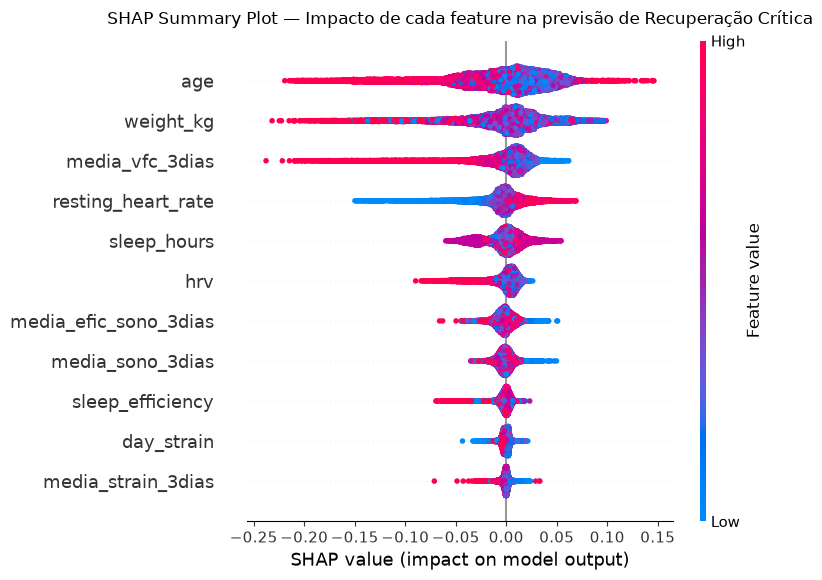

✅ Salvo em 'shap_summary_plot.png'

📊 Gerando Bar Plot SHAP...


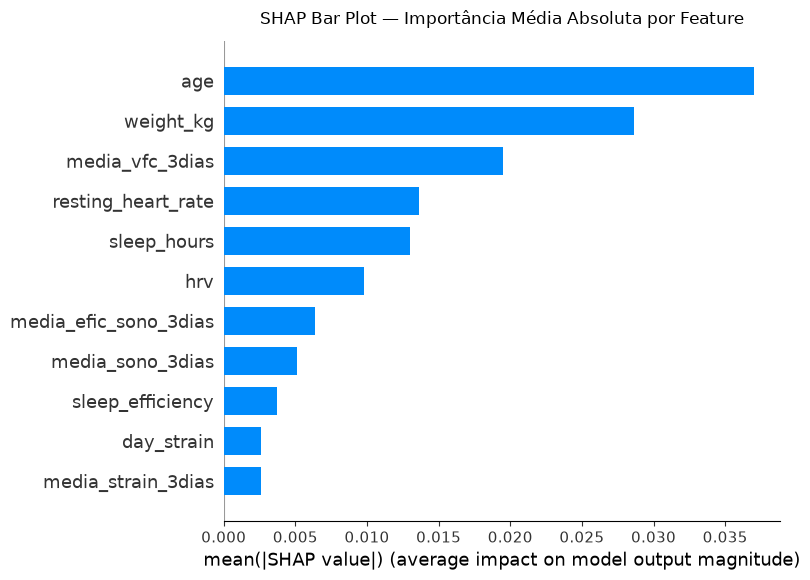

✅ Salvo em 'shap_bar_plot.png'

📊 Gerando Waterfall Plot (caso mais crítico)...


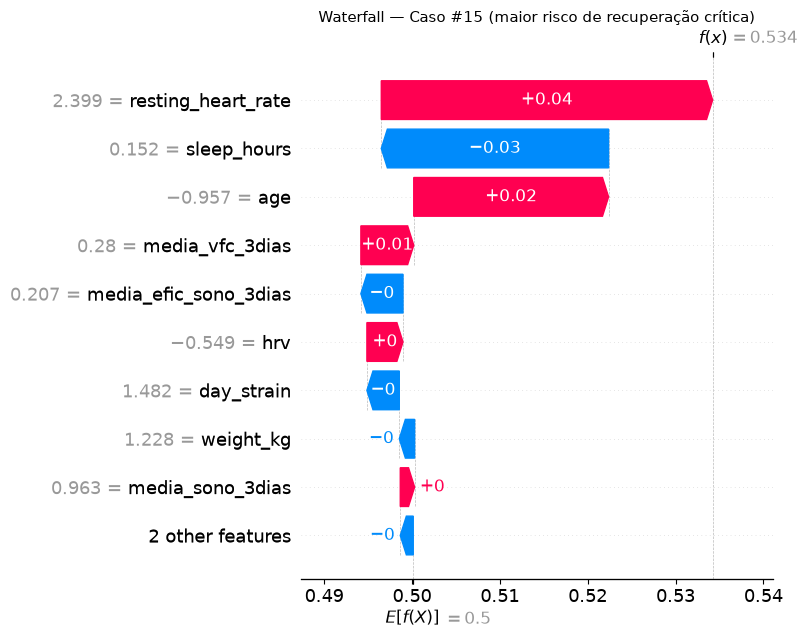

✅ Salvo em 'shap_waterfall.png'


In [12]:
# ==========================================================
# CÉLULA 10 — XAI com SHAP (modelo PISI) - VERSÃO CORRIGIDA CLÁSSICA
# ==========================================================
print("⏳ Calculando valores SHAP para o modelo PISI...")

# Extrair os dados já transformados (sem SMOTE — SHAP usa só o conjunto de teste)
X_test_proc = pipeline_pisi.named_steps['imputer'].transform(X_test)
X_test_proc = pipeline_pisi.named_steps['scaler'].transform(X_test_proc)
X_test_proc_df = pd.DataFrame(X_test_proc, columns=FEATURES)

clf = pipeline_pisi.named_steps['classifier']
explainer = shap.TreeExplainer(clf)

shap_values_raw = explainer.shap_values(X_test_proc_df)

if isinstance(shap_values_raw, list):
    sv_class1 = np.asarray(shap_values_raw[1])
elif hasattr(shap_values_raw, 'values'):
    if len(shap_values_raw.values.shape) == 3:
        sv_class1 = np.asarray(shap_values_raw.values[:, :, 1])
    else:
        sv_class1 = np.asarray(shap_values_raw.values)
else:
    sv_class1 = np.asarray(shap_values_raw)

if len(sv_class1.shape) == 3:
    sv_class1 = sv_class1[:, :, 1]

print("✅ Valores SHAP calculados e normalizados!")
print(f"   Shape final dos valores SHAP: {sv_class1.shape} (Precisa ser 2D!)")

# --- Gráfico 1: Summary Plot (Beeswarm) ---
print("\n📊 Gerando Summary Plot SHAP Tradicional...")
plt.figure(figsize=(10, 6))


shap.summary_plot(
    sv_class1, 
    X_test_proc_df.to_numpy(), 
    feature_names=FEATURES, 
    plot_type='dot', 
    max_display=11, 
    show=False
)

plt.title('SHAP Summary Plot — Impacto de cada feature na previsão de Recuperação Crítica', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Salvo em 'shap_summary_plot.png'")

# --- Gráfico 2: Bar Plot (importância média absoluta) ---
print("\n📊 Gerando Bar Plot SHAP...")
plt.figure(figsize=(9, 5))
shap.summary_plot(
    sv_class1,
    X_test_proc_df.to_numpy(),
    feature_names=FEATURES,
    plot_type='bar',
    max_display=11,
    show=False
)
plt.title('SHAP Bar Plot — Importância Média Absoluta por Feature', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Salvo em 'shap_bar_plot.png'")

# --- Gráfico 3: Waterfall do caso mais crítico (explicação individual) ---
print("\n📊 Gerando Waterfall Plot (caso mais crítico)...")
idx_mais_critico = np.argmax(pipeline_pisi.predict_proba(X_test_proc_df)[:, 1])

try:
    shap_exp_class1 = shap.Explanation(
        values=sv_class1,
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
        data=X_test_proc_df.to_numpy(),
        feature_names=FEATURES
    )

    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_exp_class1[idx_mais_critico], show=False)
    plt.title(f'Waterfall — Caso #{idx_mais_critico} (maior risco de recuperação crítica)', fontsize=11)
    plt.tight_layout()
    plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Salvo em 'shap_waterfall.png'")
except Exception as e:
    print(f"⚠️ Waterfall não disponível nesta versão do SHAP: {e}")


In [13]:
# ==========================================================
# CÉLULA 11 — Validação Cruzada (robustez do modelo)
# ==========================================================
print("⏳ Calculando validação cruzada (5-fold estratificado)...")

# Usamos a pipeline completa para não vazar dados de validação
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-val calcula sobre dados de treino (X_train, y_train)
scores_auc  = cross_val_score(pipeline_pisi, X_train, y_train,
                               scoring='roc_auc', cv=cv, n_jobs=-1)
scores_f1   = cross_val_score(pipeline_pisi, X_train, y_train,
                               scoring='f1', cv=cv, n_jobs=-1)

print("\n" + "="*50)
print("  VALIDAÇÃO CRUZADA 5-Fold — Modelo PISI")
print("="*50)
print(f"  AUC-ROC : {scores_auc.mean():.3f} ± {scores_auc.std():.3f}")
print(f"  F1      : {scores_f1.mean():.3f} ± {scores_f1.std():.3f}")
print("(Baixo desvio padrão indica modelo estável)")

⏳ Calculando validação cruzada (5-fold estratificado)...

  VALIDAÇÃO CRUZADA 5-Fold — Modelo PISI
  AUC-ROC : 0.677 ± 0.006
  F1      : 0.533 ± 0.005
(Baixo desvio padrão indica modelo estável)


In [14]:
# ==========================================================
# CÉLULA 12 — Resumo final para o relatório
# ==========================================================
print("\n" + "="*65)
print("  RESUMO FINAL — PISI")
print("="*65)
print(f"""
Target utilizado : Recovery Score do dia seguinte < {LIMIAR:.0f} (p33)
Balanceamento    : SMOTE (k_neighbors=5) aplicado SOMENTE no treino
Features         : {len(FEATURES)} variáveis (fisiológicas + médias móveis 3 dias)
Split            : 80% treino / 20% teste (estratificado)
XAI              : SHAP TreeExplainer

Resultado PISI (RF + SMOTE):
  AUC-ROC  : {roc_auc_score(y_test, y_proba_pisi):.3f}
  F1 (cl.1): {f1_score(y_test, y_pred_pisi):.3f}
  Recall   : {recall_score(y_test, y_pred_pisi):.3f}

Resultado 3VA (Gradient Boosting):
  AUC-ROC  : {roc_auc_score(y_test, y_proba_3va):.3f}
  F1 (cl.1): {f1_score(y_test, y_pred_3va):.3f}
  Recall   : {recall_score(y_test, y_pred_3va):.3f}
""")


  RESUMO FINAL — PISI

Target utilizado : Recovery Score do dia seguinte < 57 (p33)
Balanceamento    : SMOTE (k_neighbors=5) aplicado SOMENTE no treino
Features         : 11 variáveis (fisiológicas + médias móveis 3 dias)
Split            : 80% treino / 20% teste (estratificado)
XAI              : SHAP TreeExplainer

Resultado PISI (RF + SMOTE):
  AUC-ROC  : 0.685
  F1 (cl.1): 0.541
  Recall   : 0.632

Resultado 3VA (Gradient Boosting):
  AUC-ROC  : 0.709
  F1 (cl.1): 0.396
  Recall   : 0.295

